<a href="https://www.kaggle.com/code/sonawanelalitsunil/e-commerce-product-performance-ml-90-27?scriptVersionId=237626808" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/e-commerce-product-performance-dataset/ecommerce_product_performance.csv


## Title : 
E-Commerce Product Performance Data

## Description:
Dataset capturing product-level sales, ratings, and customer interaction metrics to analyze performance trends in an online store.

## Import Dataset

In [2]:
df = pd.read_csv('/kaggle/input/e-commerce-product-performance-dataset/ecommerce_product_performance.csv')

In [3]:
df.head()

,Product_Price,Discount_Rate,Product_Rating,Number_of_Reviews,Stock_Availability,Days_to_Deliver,Return_Rate,Category_ID
0,199.671415,0.177024,4.411071,62.0,1.0,9.0,0.185116,5.0
1,136.173570,0.041467,3.033534,201.0,1.0,3.0,0.384639,10.0
2,214.768854,0.276197,2.866881,479.0,1.0,19.0,0.056410,4.0
3,302.302986,0.094254,4.473473,252.0,1.0,11.0,NaN,7.0
4,126.584663,0.411845,3.553082,671.0,1.0,14.0,0.672163,6.0


In [4]:
df.tail()

,Product_Price,Discount_Rate,Product_Rating,Number_of_Reviews,Stock_Availability,Days_to_Deliver,Return_Rate,Category_ID
1995,257.015024,0.098708,3.805205,398.0,1.0,7.0,NaN,5.0
1996,NaN,0.679901,3.340395,788.0,NaN,17.0,0.195181,10.0
1997,61.812535,0.081616,2.736741,297.0,1.0,7.0,0.293520,7.0
1998,133.693304,0.346151,3.246759,467.0,1.0,6.0,0.362834,8.0
1999,75.509736,0.669742,3.226297,56.0,1.0,5.0,0.204589,3.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Product_Price       1900 non-null   float64
 1   Discount_Rate       1900 non-null   float64
 2   Product_Rating      1900 non-null   float64
 3   Number_of_Reviews   1900 non-null   float64
 4   Stock_Availability  1900 non-null   float64
 5   Days_to_Deliver     1900 non-null   float64
 6   Return_Rate         1900 non-null   float64
 7   Category_ID         1900 non-null   float64
dtypes: float64(8)
memory usage: 125.1 KB


In [6]:
df.describe()

,Product_Price,Discount_Rate,Product_Rating,Number_of_Reviews,Stock_Availability,Days_to_Deliver,Return_Rate,Category_ID
count,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000
mean,156.774274,0.286993,3.729987,304.318421,0.903158,15.411579,0.328904,5.572105
std,93.484558,0.159012,0.885164,310.344539,0.295821,8.534049,0.176306,2.827601
min,5.000000,0.005368,1.000000,0.000000,0.000000,1.000000,0.006528,1.000000
25%,87.414867,0.165603,3.125828,86.750000,1.000000,8.000000,0.190178,3.000000
50%,153.663352,0.265994,3.770215,210.000000,1.000000,15.000000,0.307430,6.000000
75%,217.788796,0.391186,4.417711,429.000000,1.000000,22.000000,0.444752,8.000000
max,535.273149,0.800000,5.000000,2848.000000,1.000000,30.000000,0.900000,10.000000


In [7]:
df.isnull().sum()

Product_Price         100
Discount_Rate         100
Product_Rating        100
Number_of_Reviews     100
Stock_Availability    100
Days_to_Deliver       100
Return_Rate           100
Category_ID           100
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

Product_Price         float64
Discount_Rate         float64
Product_Rating        float64
Number_of_Reviews     float64
Stock_Availability    float64
Days_to_Deliver       float64
Return_Rate           float64
Category_ID           float64
dtype: object

In [10]:
df.shape

(2000, 8)

In [11]:
df.columns

Index(['Product_Price', 'Discount_Rate', 'Product_Rating', 'Number_of_Reviews',
       'Stock_Availability', 'Days_to_Deliver', 'Return_Rate', 'Category_ID'],
      dtype='object')

## Data visualizations

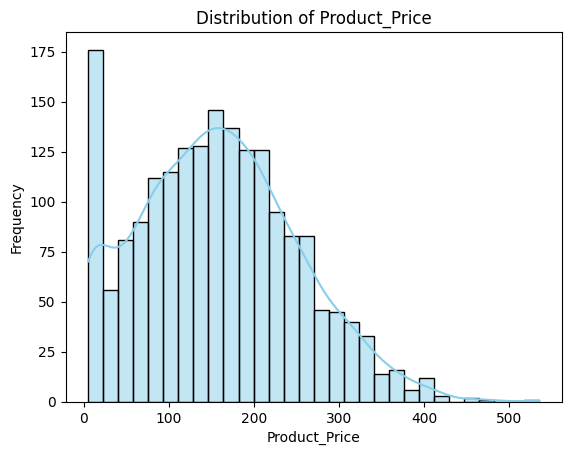

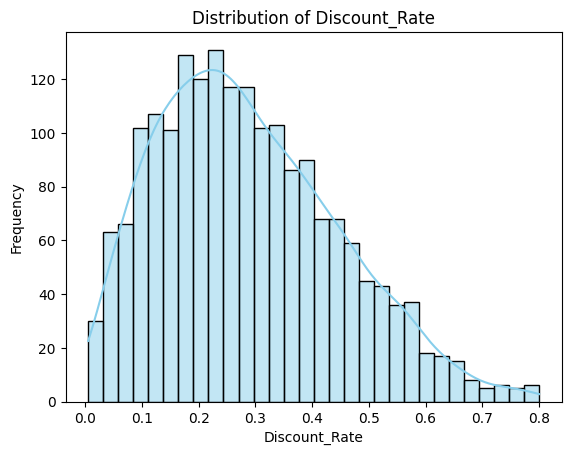

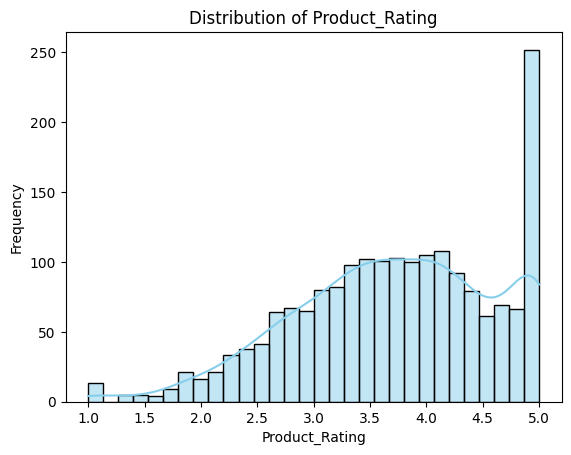

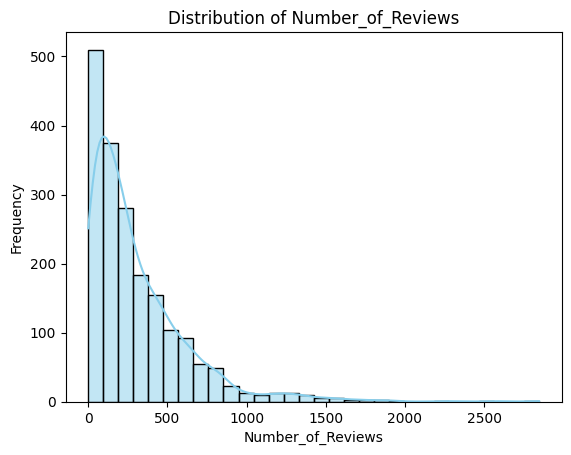

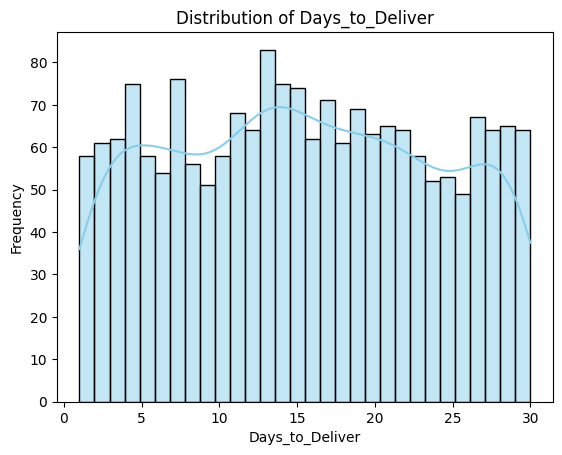

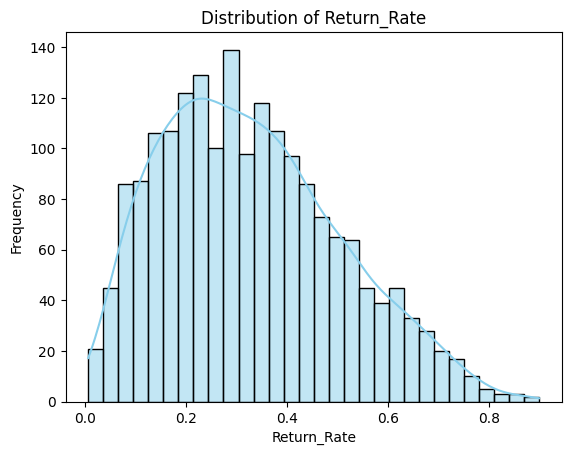

In [12]:
# List of continuous variables
continuous_cols = ['Product_Price', 'Discount_Rate', 'Product_Rating', 'Number_of_Reviews', 'Days_to_Deliver', 'Return_Rate']

# Plot distribution
for col in continuous_cols:
    plt.figure()
    sns.histplot(data=df, x=col, kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


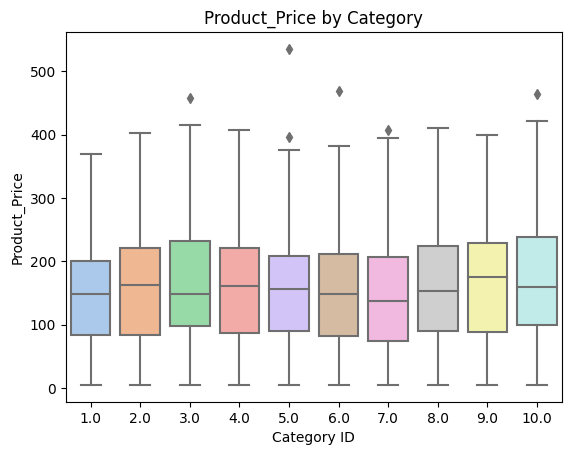

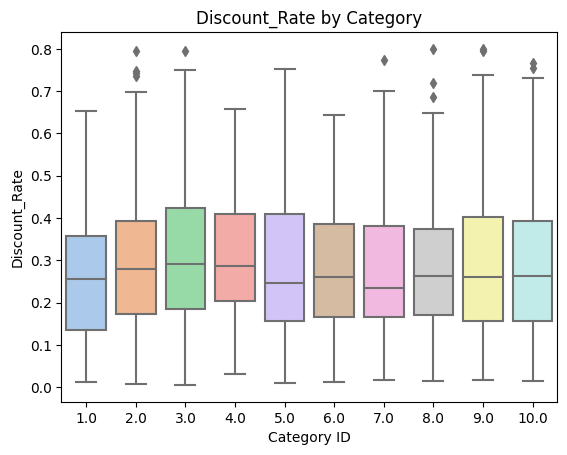

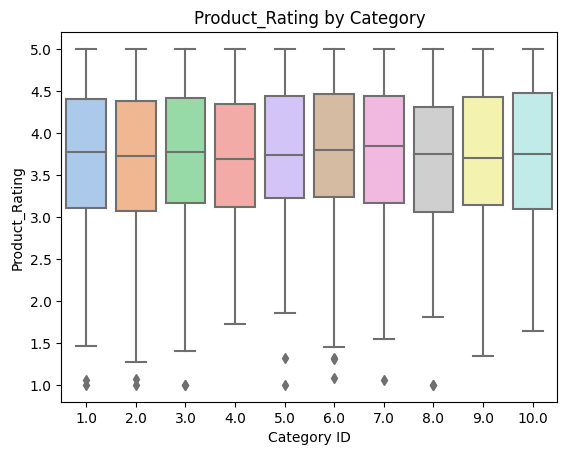

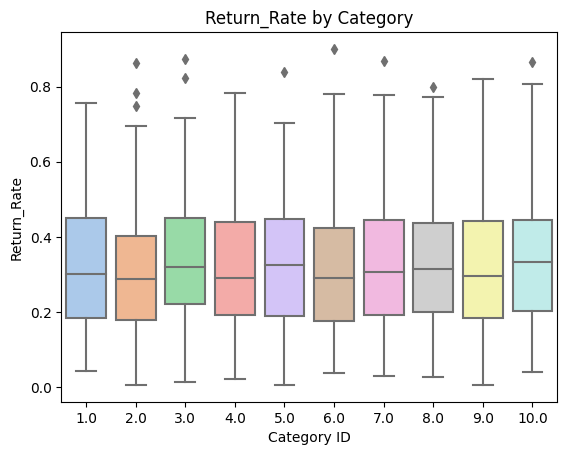

In [13]:
# Boxplots to compare value distributions by Category_ID
for col in ['Product_Price', 'Discount_Rate', 'Product_Rating', 'Return_Rate']:
    plt.figure()
    sns.boxplot(data=df, x='Category_ID', y=col, palette='pastel')
    plt.title(f'{col} by Category')
    plt.xlabel('Category ID')
    plt.ylabel(col)
    plt.show()


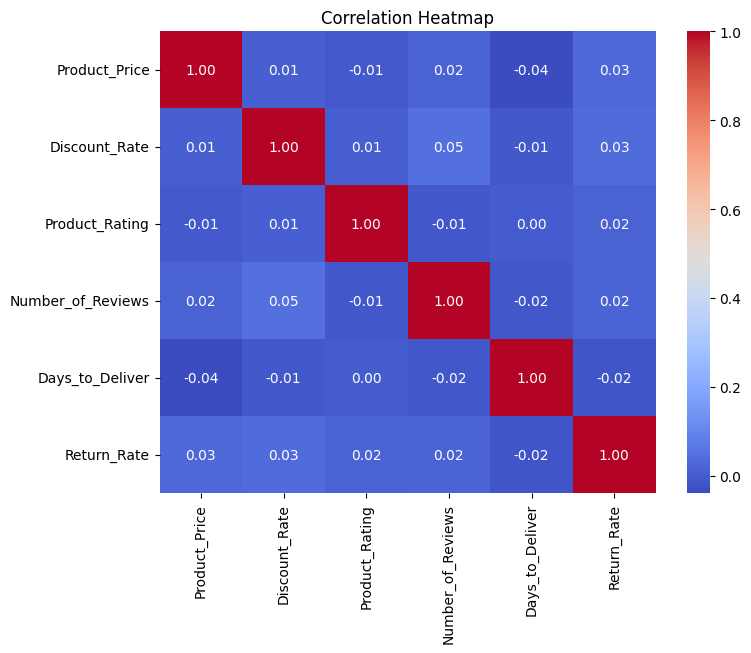

In [14]:
# Correlation heatmap for continuous features
plt.figure(figsize=(8, 6))
sns.heatmap(df[continuous_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


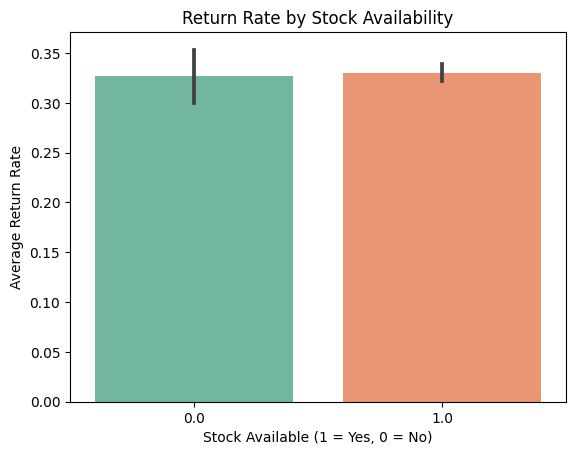

In [15]:
# Compare average return rate based on stock availability
plt.figure()
sns.barplot(data=df, x='Stock_Availability', y='Return_Rate', palette='Set2')
plt.title('Return Rate by Stock Availability')
plt.xlabel('Stock Available (1 = Yes, 0 = No)')
plt.ylabel('Average Return Rate')
plt.show()


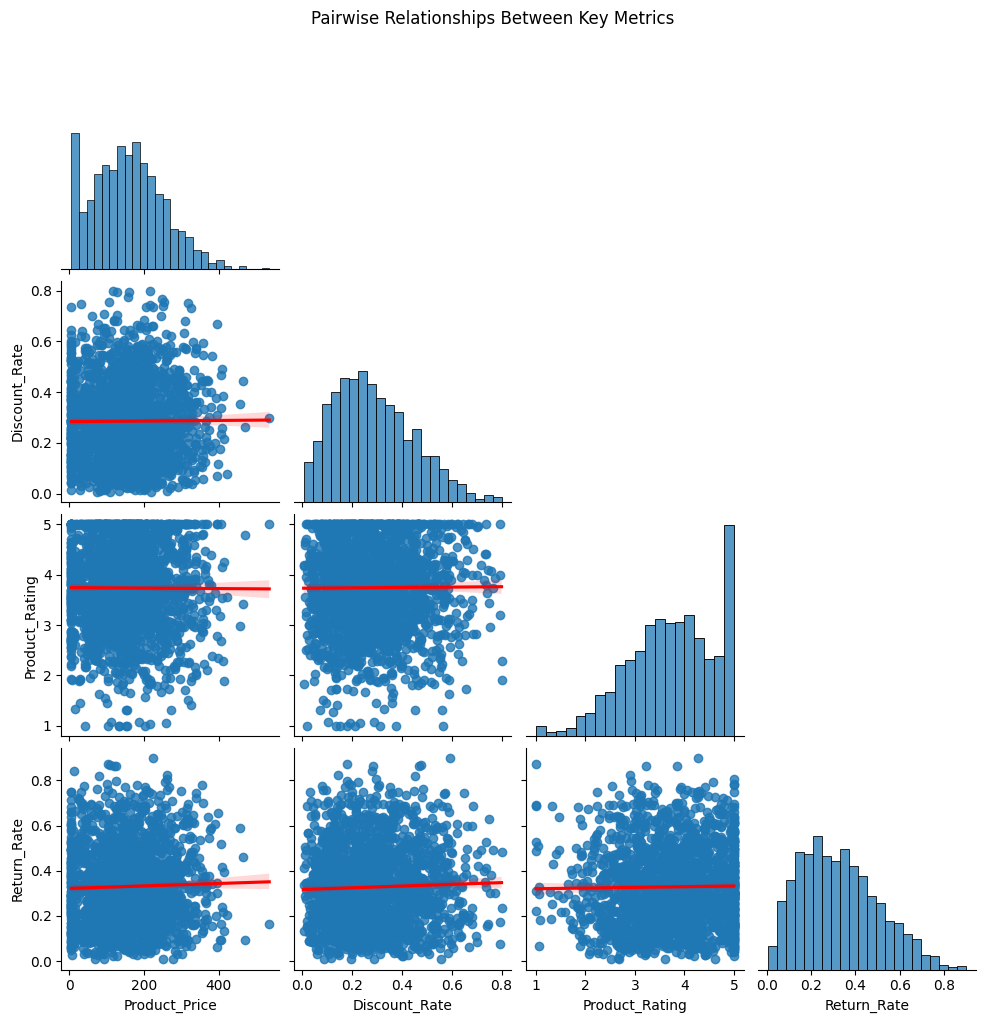

In [16]:
# Pairplot to see scatter plots between variables
key_cols = ['Product_Price', 'Discount_Rate', 'Product_Rating', 'Return_Rate']
sns.pairplot(df[key_cols], corner=True, kind='reg', plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('Pairwise Relationships Between Key Metrics', y=1.02)
plt.show()


## Predictive modeling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [19]:
# Step 0: Drop rows where target is NaN
df = df.dropna(subset=['Stock_Availability'])

# Step 1: Label encode Category_ID if it's categorical
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Category_ID'] = le.fit_transform(df['Category_ID'])

# Step 2: Separate features and target
X = df.drop('Stock_Availability', axis=1)
y = df['Stock_Availability']

# Step 3: Handle missing values in X
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Step 4: Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=42)


Logistic Regression Accuracy: 90.79%


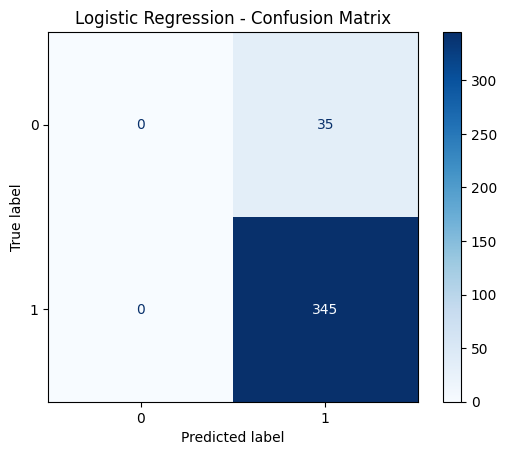


Random Forest Accuracy: 90.79%


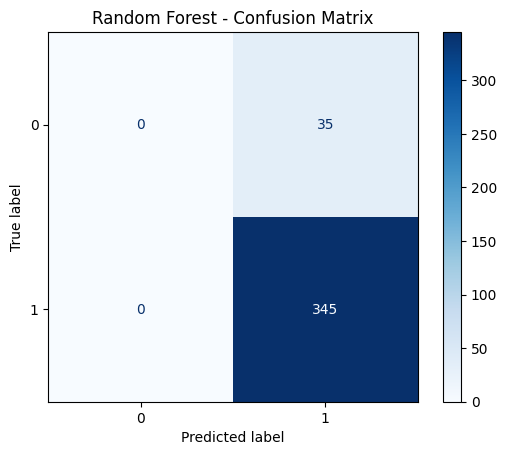


Decision Tree Accuracy: 82.63%


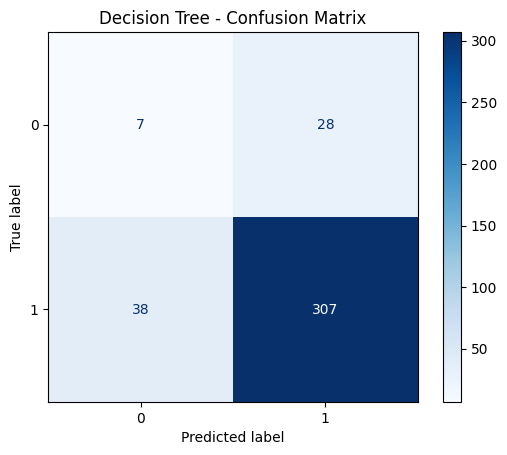


SVM Accuracy: 90.79%


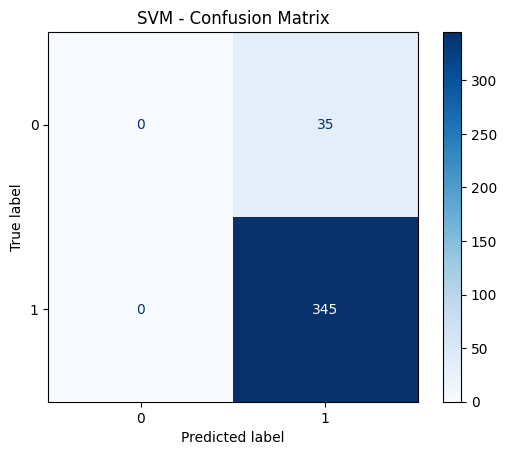


KNN Accuracy: 89.21%


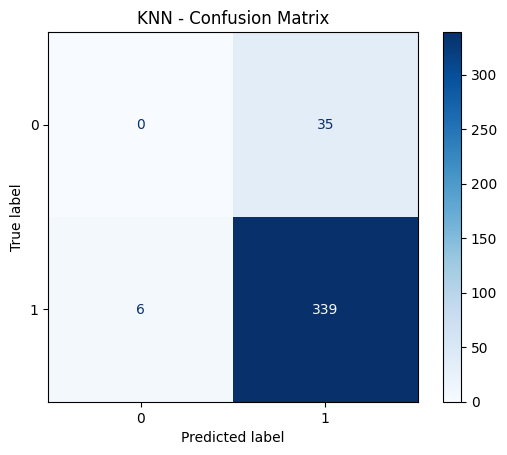


Naive Bayes Accuracy: 90.79%


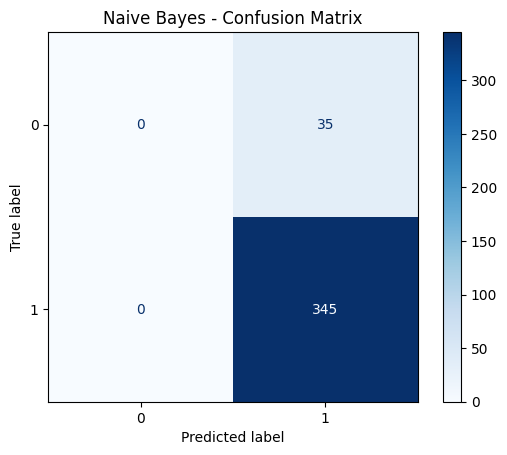

In [20]:
# Step 5: Define classifiers
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB()
}

# Step 6: Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred) * 100
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name} Accuracy: {acc:.2f}%")
    
    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.show()

## Thank you..pls upvote!!!